In [2]:
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")  # Hide warning messages for cleaner notebook output

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Optional package: LightGBM
try:
    import lightgbm as lgb
    lightgbm_available = True
except ImportError:
    lightgbm_available = False
    print("lightgbm is not installed. LightGBM cells will be skipped.")

# Optional package: XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print("xgboost is not installed. XGBoost cells will be skipped.")

# Optional package: SHAP
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print("shap is not installed. SHAP cells will be skipped.")

# Optional package: Optuna
try:
    import optuna
    optuna_available = True
except ImportError:
    optuna_available = False
    print("optuna is not installed. Optuna cells will be skipped.")

# Make pandas tables easier to read
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Set default plot size
plt.rcParams["figure.figsize"] = (14, 6)

# Forecast setup
# Keep the row timestamp as the target timestamp and only use information
# that would have been known FORECAST_HORIZON_HOURS earlier.
FORECAST_HORIZON_HOURS = 24
RAW_LAG_CANDIDATES = [1, 2, 3, 24, 48, 72, 168]
SAFE_LAGS = [lag for lag in RAW_LAG_CANDIDATES if lag > FORECAST_HORIZON_HOURS]
ROLLING_WINDOWS = [6, 12, 24, 48, 168]
SAFE_ROLLING_WINDOWS = [window for window in ROLLING_WINDOWS if window >= 24]

if not SAFE_LAGS:
    raise ValueError(
        "No leakage-safe lag features are available. Increase RAW_LAG_CANDIDATES "
        "or reduce FORECAST_HORIZON_HOURS."
    )

print(f"Forecast horizon: {FORECAST_HORIZON_HOURS} hours")
print(f"Leakage-safe lags: {SAFE_LAGS}")


Forecast horizon: 24 hours
Leakage-safe lags: [48, 72, 168]


In [3]:
# 3. LOAD DATA
# ============================================================

candidate_paths = [
    Path("df_final.csv"),
    Path("data/df_final.csv"),
    Path("/mnt/data/df_final.csv"),
    Path(r"C:\Users\wladl\Desktop\Project1\WattWise\data\df_final.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find 'df_final.csv'. Place it next to this notebook, inside a "
        "'data/' folder, or upload it to /mnt/data."
    )

df_final = pd.read_csv(data_path)

required_columns = {"timestamp", "price"}
missing_required = required_columns - set(df_final.columns)
if missing_required:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_required)}")

df = df_final.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

print(f"Dataset loaded from: {data_path}")
print("Shape:", df.shape)
display(df.head())


Dataset loaded from: C:\Users\wladl\Desktop\Project1\WattWise\data\df_final.csv
Shape: (62728, 30)


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,co2_price,is_holiday,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load
0,2019-01-08 00:00:00,17.94,51472.75,4520.75,32832.00,0.0,0,1,1,5.0000,38.297380,False,22.09,82.150002,46.03,28.32,50.642083,39.621845,22.4,False,False,68405.50,13001.0,10497.25,3789.00,8675.50,3505.75,33982.00,0.0,54342.75
1,2019-01-08 01:00:00,20.91,49815.00,4397.00,33236.50,0.0,1,1,1,5.1250,42.214985,False,22.09,82.150002,47.98,10.07,49.514167,39.686369,22.4,False,False,68068.25,13461.0,10096.25,3614.00,8958.50,3552.00,33866.00,0.0,52541.75
2,2019-01-08 02:00:00,7.78,49241.75,4379.00,33473.50,0.0,2,1,1,4.9875,41.856293,False,22.09,82.150002,47.84,-4.08,47.845000,39.756964,22.4,False,False,67413.75,13093.0,9980.50,3599.00,8720.75,3463.75,33839.50,0.0,51658.75
3,2019-01-08 03:00:00,14.33,49512.25,4134.75,33843.25,0.0,3,1,1,4.8625,43.862682,False,22.09,82.150002,46.11,-9.91,46.520833,39.901250,22.4,False,False,68034.50,13258.0,9996.25,3709.75,8878.75,3473.25,34115.75,0.0,52231.75
4,2019-01-08 04:00:00,18.56,50572.75,3871.50,34549.75,0.0,4,1,1,4.8000,45.394573,False,22.09,82.150002,46.08,-7.41,45.374167,40.055833,22.4,False,False,68487.00,13182.0,10178.50,3971.25,8970.75,3129.75,34217.25,0.0,53853.50


In [4]:
# 4. MISSING VALUE TREATMENT
# ============================================================

df = df.dropna(subset=["price"]).copy()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
predictor_numeric_cols = [col for col in numeric_cols if col != "price"]

df[predictor_numeric_cols] = df[predictor_numeric_cols].ffill().bfill()

remaining_missing = df.isna().sum().sort_values(ascending=False)
display(remaining_missing[remaining_missing > 0].head(30))

Series([], dtype: int64)

In [5]:
# 5. FEATURE ENGINEERING
# ============================================================

# Calendar
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month
df["day_of_month"] = df["timestamp"].dt.day
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Lag features
# Use only lags that are strictly larger than the forecast horizon.
for lag in SAFE_LAGS:
    df[f"price_lag_{lag}"] = df["price"].shift(lag)

# Rolling features
# The last value allowed in the rolling window must also be older than the
# forecast horizon, so we shift by (horizon + 1) before rolling.
for window in SAFE_ROLLING_WINDOWS:
    df[f"price_roll_mean_{window}"] = df["price"].shift(FORECAST_HORIZON_HOURS + 1).rolling(window=window).mean()
    df[f"price_roll_std_{window}"] = df["price"].shift(FORECAST_HORIZON_HOURS + 1).rolling(window=window).std()

# Renewable totals
renewable_cols = [col for col in ["wind_offshore", "wind_onshore", "solar"] if col in df.columns]
if renewable_cols:
    df["renewable_total"] = df[renewable_cols].sum(axis=1)
else:
    df["renewable_total"] = np.nan

# Load used
if "load" in df.columns:
    df["load_used"] = df["load"]
elif "actual_load" in df.columns:
    df["load_used"] = df["actual_load"]
else:
    df["load_used"] = np.nan

# Market structure
df["renewable_penetration_ratio"] = np.where(
    df["load_used"] > 0,
    df["renewable_total"] / df["load_used"],
    np.nan
)
df["residual_load"] = df["load_used"] - df["renewable_total"]

# Forecast error features if available
forecast_actual_pairs = [
    ("load", "actual_load"),
    ("solar", "actual_solar"),
    ("wind_onshore", "actual_wind_onshore"),
    ("wind_offshore", "actual_wind_offshore")
]

for forecast_col, actual_col in forecast_actual_pairs:
    if forecast_col in df.columns and actual_col in df.columns:
        df[f"{forecast_col}_error"] = df[forecast_col] - df[actual_col]

print("Created lag features:", [f"price_lag_{lag}" for lag in SAFE_LAGS])
print("Created rolling windows:", SAFE_ROLLING_WINDOWS)


Created lag features: ['price_lag_48', 'price_lag_72', 'price_lag_168']
Created rolling windows: [24, 48, 168]


In [6]:
# 6. BUILD MODELING DATASET
# ============================================================

import re

candidate_features = [
    "hour", "day_of_week", "month", "day_of_month", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    "renewable_penetration_ratio", "residual_load",
    "load", "wind_offshore", "wind_onshore", "solar",
    "temperature", "wind_speed", "gas_price", "coal_price", "co2_price"
]

def extract_trailing_number(col_name):
    match = re.search(r"(\d+)(?:h)?$", col_name)
    return int(match.group(1)) if match else None

# Keep only leakage-safe lag and rolling features, even if the source data
# already contains precomputed columns such as price_lag_24h.
safe_existing_lag_features = []
excluded_lag_features = []
for col in df.columns:
    if col.startswith("price_lag_"):
        lag_value = extract_trailing_number(col)
        if lag_value is None:
            excluded_lag_features.append(col)
        elif lag_value > FORECAST_HORIZON_HOURS:
            safe_existing_lag_features.append(col)
        else:
            excluded_lag_features.append(col)

safe_existing_roll_features = []
excluded_roll_features = []
for col in df.columns:
    if col.startswith("price_roll_mean_") or col.startswith("price_roll_std_"):
        window_value = extract_trailing_number(col)
        if window_value is None:
            excluded_roll_features.append(col)
        else:
            safe_existing_roll_features.append(col)

candidate_features += safe_existing_lag_features
candidate_features += safe_existing_roll_features
candidate_features += [col for col in df.columns if col.endswith("_error")]

feature_cols = [col for col in candidate_features if col in df.columns]
feature_cols = list(dict.fromkeys(feature_cols))  # remove duplicates while preserving order

target_col = "price"

unsafe_features = []
for col in feature_cols:
    if col.startswith("price_lag_"):
        lag_value = extract_trailing_number(col)
        if lag_value is None or lag_value <= FORECAST_HORIZON_HOURS:
            unsafe_features.append(col)

if unsafe_features:
    raise ValueError(f"Unsafe lag features detected after filtering: {unsafe_features}")

df_model = df.dropna(subset=feature_cols + [target_col]).copy()

X = df_model[feature_cols]
y = df_model[target_col]

print("Modeling rows:", len(df_model))
print("Feature count:", len(feature_cols))
print("Forecast horizon used for leakage checks:", FORECAST_HORIZON_HOURS)
if excluded_lag_features:
    print("Excluded unsafe/unparseable lag features:", excluded_lag_features)
if excluded_roll_features:
    print("Excluded unparseable rolling features:", excluded_roll_features)
display(feature_cols[:50])



Modeling rows: 62536
Feature count: 36
Forecast horizon used for leakage checks: 24
Excluded unsafe/unparseable lag features: ['price_lag_24h']


['hour',
 'day_of_week',
 'month',
 'day_of_month',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'month_sin',
 'month_cos',
 'renewable_penetration_ratio',
 'residual_load',
 'load',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'temperature',
 'wind_speed',
 'gas_price',
 'coal_price',
 'co2_price',
 'price_lag_168h',
 'price_lag_48',
 'price_lag_72',
 'price_lag_168',
 'price_roll_mean_24',
 'price_roll_std_24',
 'price_roll_mean_48',
 'price_roll_std_48',
 'price_roll_mean_168',
 'price_roll_std_168',
 'load_error',
 'solar_error',
 'wind_onshore_error',
 'wind_offshore_error']

In [7]:
# 7. TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

n = len(df_model)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_model.iloc[:train_end].copy()
val_df = df_model.iloc[train_end:val_end].copy()
test_df = df_model.iloc[val_end:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))
print(train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print(val_df["timestamp"].min(), "->", val_df["timestamp"].max())
print(test_df["timestamp"].min(), "->", test_df["timestamp"].max())

Train rows: 43775
Validation rows: 9380
Test rows: 9381
2019-01-16 00:00:00 -> 2024-01-14 03:00:00
2024-01-14 04:00:00 -> 2025-02-08 00:00:00
2025-02-08 01:00:00 -> 2026-03-05 22:00:00


In [8]:
# 8. EVALUATION HELPERS
# ============================================================

def evaluate_predictions(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    #rmse = mean_squared_error(y_true, y_pred, squared=False)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return pd.DataFrame({
        "model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse]
    })

def collect_metrics(y_true, pred_dict, prefix="Validation"):
    rows = []
    for model_name, preds in pred_dict.items():
        rows.append(evaluate_predictions(y_true, preds, f"{model_name}_{prefix}"))
    return pd.concat(rows, ignore_index=True).sort_values("MAE").reset_index(drop=True)


In [9]:
# 9A. NAIVE BASELINES
# ============================================================

baseline_lags = [SAFE_LAGS[0], SAFE_LAGS[-1]] if len(SAFE_LAGS) > 1 else [SAFE_LAGS[0]]
baseline_lags = list(dict.fromkeys(baseline_lags))

baseline_val_pred_dict = {}
baseline_test_pred_dict = {}

for lag in baseline_lags:
    model_name = f"Naive{lag}"
    lag_col = f"price_lag_{lag}"
    baseline_val_pred_dict[model_name] = val_df[lag_col]
    baseline_test_pred_dict[model_name] = test_df[lag_col]

baseline_val_results = collect_metrics(y_val, baseline_val_pred_dict, prefix="Validation")
baseline_test_results = collect_metrics(y_test, baseline_test_pred_dict, prefix="Test")

display(baseline_val_results)
display(baseline_test_results)


,model,MAE,RMSE
0,Naive168_Validation,34.101945,56.911220
1,Naive48_Validation,36.193316,57.669184


,model,MAE,RMSE
0,Naive168_Test,29.690204,44.986689
1,Naive48_Test,30.982539,46.347358


In [10]:
# 9B. RIDGE BASELINE
# ============================================================

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

val_pred_ridge = ridge_model.predict(X_val)
test_pred_ridge = ridge_model.predict(X_test)

display(evaluate_predictions(y_val, val_pred_ridge, "Ridge_Validation"))
display(evaluate_predictions(y_test, test_pred_ridge, "Ridge_Test"))

,model,MAE,RMSE
0,Ridge_Validation,19.934672,33.501816


,model,MAE,RMSE
0,Ridge_Test,20.077742,27.849342


# Hyperparameter tuning strategy

We optimize tree-based models because they are likely the strongest tabular models for this problem.

Two tuning paths are included:
- simple GridSearch-style loop
- Optuna, if installed

We tune on the validation set only.
The test set remains untouched until model selection is complete.

In [11]:
# 10A. LIGHTGBM GRID SEARCH
# ============================================================

best_lgb_model = None
best_lgb_score = np.inf
best_lgb_params = None

if lightgbm_available:
    param_grid = {
        "n_estimators": [200, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [-1, 6, 10],
        "num_leaves": [31, 63],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }

    for params in ParameterGrid(param_grid):
        model = lgb.LGBMRegressor(
            objective="regression",
            random_state=42,
            **params
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)

        if mae < best_lgb_score:
            best_lgb_score = mae
            best_lgb_model = model
            best_lgb_params = params

    print("Best LightGBM validation MAE:", best_lgb_score)
    print("Best LightGBM params:", best_lgb_params)
else:
    print("Skipping LightGBM grid search because lightgbm is not installed.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004632 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 43775, number of used features: 36
[LightGBM] [Info] Start training from score 99.458752
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004656 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 43775, number of used features: 36
[LightGBM] [Info] Start training from score 99.458752
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001912 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train s

##  LightGBM tuning

This performs a simple grid search over a small parameter space.

That is often enough to get a strong first optimized model without making the notebook too heavy.

In [12]:
# Optional installation helper (run only if needed)
# %pip install xgboost


In [13]:
# 10B. XGBOOST GRID SEARCH
# ============================================================

best_xgb_model = None
best_xgb_score = np.inf
best_xgb_params = None

if xgb_available:
    param_grid = {
        "n_estimators": [200, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [4, 6, 8],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }

    for params in ParameterGrid(param_grid):
        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            **params
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)

        if mae < best_xgb_score:
            best_xgb_score = mae
            best_xgb_model = model
            best_xgb_params = params

    print("Best XGBoost validation MAE:", best_xgb_score)
    print("Best XGBoost params:", best_xgb_params)
else:
    print("Skipping XGBoost grid search because xgboost is not installed.")

Best XGBoost validation MAE: 14.026852024747068
Best XGBoost params: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}


## 10B. XGBoost tuning

This applies the same logic to XGBoost.

We tune only on training and validation.
The test set is still untouched.

In [14]:
# 10C. OPTIONAL OPTUNA FOR LIGHTGBM
# ============================================================

if lightgbm_available and optuna_available:
    def objective_lgb(trial):
        params = {
            "objective": "regression",
            "random_state": 42,
            "n_estimators": trial.suggest_int("n_estimators", 150, 600),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15),
            "num_leaves": trial.suggest_int("num_leaves", 20, 100),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0)
        }

        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return mean_absolute_error(y_val, preds)

    study_lgb = optuna.create_study(direction="minimize")
    study_lgb.optimize(objective_lgb, n_trials=25)

    print("Best Optuna LightGBM MAE:", study_lgb.best_value)
    print("Best Optuna LightGBM params:", study_lgb.best_params)
else:
    print("Skipping Optuna tuning.")

[I 2026-03-25 20:03:27,921] A new study created in memory with name: no-name-08bb4de6-e5e9-43a4-aadd-d26b55a5e2d1


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 43775, number of used features: 36
[LightGBM] [Info] Start training from score 99.458752
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-03-25 20:03:30,170] Trial 0 finished with value: 14.24461836619926 and parameters: {'n_estimators': 409, 'learning_rate': 0.11836189202330703, 'num_leaves': 59, 'max_depth': 10, 'subsample': 0.700110734920496, 'colsample_bytree': 0.9635319044094508}. Best is trial 0 with value: 14.24461836619926.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 43775, number of used features: 36
[LightGBM] [Info] Start training from score 99.458752


[I 2026-03-25 20:03:30,754] Trial 1 finished with value: 14.548313594286254 and parameters: {'n_estimators': 198, 'learning_rate': 0.06021506175909788, 'num_leaves': 20, 'max_depth': 11, 'subsample': 0.829573270051251, 'colsample_bytree': 0.8439559383496044}. Best is trial 0 with value: 14.24461836619926.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005828 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 43775, number of used features: 36
[LightGBM] [Info] Start training from score 99.458752
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-03-25 20:04:07,302] Trial 23 finished with value: 13.990181004524574 and parameters: {'n_estimators': 283, 'learning_rate': 0.04912304850768315, 'num_leaves': 93, 'max_depth': 6, 'subsample': 0.873114624635518, 'colsample_bytree': 0.8816319080944678}. Best is trial 22 with value: 13.876119625176555.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006363 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 43775, number of used features: 36
[LightGBM] [Info] Start training from score 99.458752
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-03-25 20:04:08,788] Trial 24 finished with value: 13.880402095898937 and parameters: {'n_estimators': 335, 'learning_rate': 0.07065211343389934, 'num_leaves': 100, 'max_depth': 7, 'subsample': 0.7784277901206764, 'colsample_bytree': 0.9324380047274123}. Best is trial 22 with value: 13.876119625176555.


Best Optuna LightGBM MAE: 13.876119625176555
Best Optuna LightGBM params: {'n_estimators': 274, 'learning_rate': 0.048247307431536234, 'num_leaves': 94, 'max_depth': 7, 'subsample': 0.8497527505988406, 'colsample_bytree': 0.8739613694612023}


## 10C. Optional Optuna tuning

Use this if you want a more efficient search than a manual grid.

It is optional because it requires an extra package and takes longer to run.

Selected best tree model: LightGBM


,feature,importance
12,residual_load,2193
21,co2_price,1237
19,gas_price,1177
20,coal_price,1106
32,load_error,839
31,price_roll_std_168,743
17,temperature,659
30,price_roll_mean_168,658
13,load,651
11,renewable_penetration_ratio,634


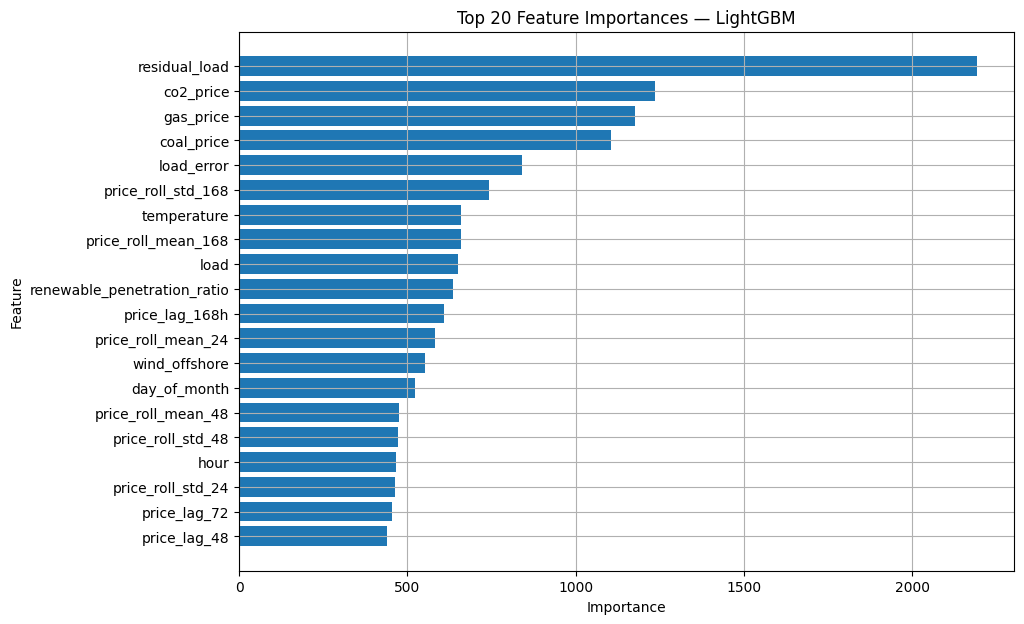

In [15]:
# 11A. FEATURE IMPORTANCE FROM BEST TREE MODEL
# ============================================================

best_tree_model = None
best_tree_name = None

tree_candidates = []

if best_lgb_model is not None:
    tree_candidates.append(("LightGBM", best_lgb_model, best_lgb_score))
if best_xgb_model is not None:
    tree_candidates.append(("XGBoost", best_xgb_model, best_xgb_score))

if tree_candidates:
    best_tree_name, best_tree_model, best_tree_score = sorted(tree_candidates, key=lambda x: x[2])[0]
    print("Selected best tree model:", best_tree_name)

    if best_tree_name == "LightGBM":
        importances = best_tree_model.feature_importances_
    else:
        importances = best_tree_model.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": importances
    }).sort_values("importance", ascending=False)

    display(importance_df.head(25))

    top_imp = importance_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 7))
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.title(f"Top 20 Feature Importances — {best_tree_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.grid(True)
    plt.show()
else:
    print("No tuned tree model available.")

## 11A. Feature importance

This gives a ranking of which inputs the best tree model relies on most strongly.

This helps identify:
- useful predictors
- weak predictors
- candidates for feature selection

In [16]:
# 11B. FEATURE SELECTION USING IMPORTANCE RANKING
# ============================================================

if tree_candidates:
    selected_top_n = 20
    selected_features = importance_df.head(selected_top_n)["feature"].tolist()

    print("Selected top features:")
    print(selected_features)

    X_train_sel = X_train[selected_features]
    X_val_sel = X_val[selected_features]
    X_test_sel = X_test[selected_features]
else:
    selected_features = feature_cols
    X_train_sel = X_train.copy()
    X_val_sel = X_val.copy()
    X_test_sel = X_test.copy()

Selected top features:
['residual_load', 'co2_price', 'gas_price', 'coal_price', 'load_error', 'price_roll_std_168', 'temperature', 'price_roll_mean_168', 'load', 'renewable_penetration_ratio', 'price_lag_168h', 'price_roll_mean_24', 'wind_offshore', 'day_of_month', 'price_roll_mean_48', 'price_roll_std_48', 'hour', 'price_roll_std_24', 'price_lag_72', 'price_lag_48']


## Feature selection

A simple first feature selection strategy is:
- rank by tree importance
- keep the top N features
- retrain and compare performance

This can reduce noise and improve generalization.

In [17]:
# 11C. RETRAIN BEST TREE MODEL ON SELECTED FEATURES
# ============================================================

best_selected_model = None
val_pred_selected = None
test_pred_selected = None

if best_tree_name == "LightGBM" and best_lgb_params is not None:
    best_selected_model = lgb.LGBMRegressor(objective="regression", random_state=42, **best_lgb_params)
elif best_tree_name == "XGBoost" and best_xgb_params is not None:
    best_selected_model = XGBRegressor(objective="reg:squarederror", random_state=42, **best_xgb_params)

if best_selected_model is not None:
    best_selected_model.fit(X_train_sel, y_train)

    val_pred_selected = best_selected_model.predict(X_val_sel)
    test_pred_selected = best_selected_model.predict(X_test_sel)

    display(evaluate_predictions(y_val, val_pred_selected, "SelectedFeatures_Validation"))
    display(evaluate_predictions(y_test, test_pred_selected, "SelectedFeatures_Test"))
else:
    print("Skipping selected-feature retraining.")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002442 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4646
[LightGBM] [Info] Number of data points in the train set: 43775, number of used features: 20
[LightGBM] [Info] Start training from score 99.458752
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,model,MAE,RMSE
0,SelectedFeatures_Validation,13.92242,29.157843


,model,MAE,RMSE
0,SelectedFeatures_Test,14.553783,23.123445


##  Retraining after selection

This checks whether removing lower-importance features improves performance.

Sometimes it helps.
Sometimes the full feature set still works better.

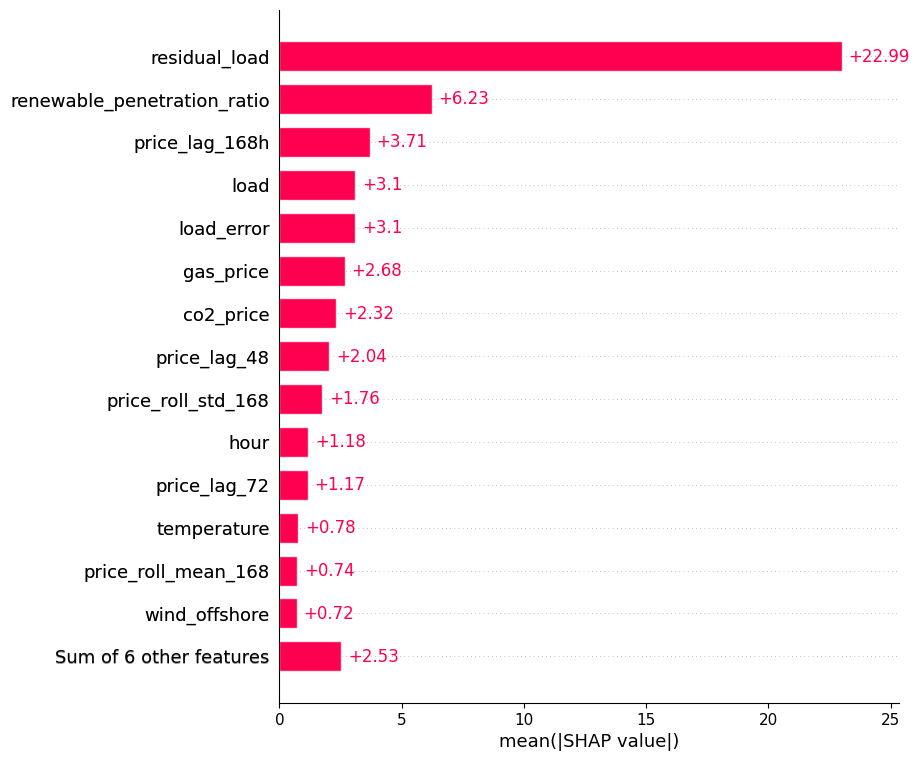

In [19]:
import shap
import pandas as pd

if "best_selected_model" in globals() and best_selected_model is not None:
    # ensure exact training feature set/order
    if hasattr(best_selected_model, "feature_names_in_"):
        expected_cols = list(best_selected_model.feature_names_in_)
        sample_X = X_val_sel[expected_cols].copy()
    else:
        sample_X = X_val_sel.copy()

    sample_X = sample_X.sample(min(1000, len(sample_X)), random_state=42)

    # build explainer
    explainer = shap.Explainer(best_selected_model, sample_X)

    # disable strict additivity check
    shap_values = explainer(sample_X, check_additivity=False)

    shap.plots.bar(shap_values, max_display=15)
else:
    print("No selected model available for SHAP analysis.")

SHAP shows how individual features contribute to predictions.

This is very useful because it explains:
- which variables matter globally
- how they push predictions up or down

In [ ]:
# 12A. MODEL COMPARISON ON VALIDATION
# ============================================================

val_pred_dict = dict(baseline_val_pred_dict)
val_pred_dict["Ridge"] = val_pred_ridge

if best_lgb_model is not None:
    val_pred_dict["LightGBM"] = best_lgb_model.predict(X_val)

if best_xgb_model is not None:
    val_pred_dict["XGBoost"] = best_xgb_model.predict(X_val)

if best_selected_model is not None and val_pred_selected is not None:
    val_pred_dict["SelectedTreeModel"] = val_pred_selected

validation_results = collect_metrics(y_val, val_pred_dict, prefix="Validation")
display(validation_results)


,model,MAE,RMSE
0,XGBoost_Validation,7.335948,15.489396
1,LightGBM_Validation,7.465019,14.988386
2,SelectedTreeModel_Validation,7.467742,15.594777
3,Ridge_Validation,9.027374,16.634729
4,Naive24_Validation,28.907185,45.989672
5,Naive168_Validation,34.085773,56.895265


In [ ]:
# 12B. MODEL COMPARISON ON TEST
# ============================================================

test_pred_dict = dict(baseline_test_pred_dict)
test_pred_dict["Ridge"] = test_pred_ridge

if best_lgb_model is not None:
    test_pred_dict["LightGBM"] = best_lgb_model.predict(X_test)

if best_xgb_model is not None:
    test_pred_dict["XGBoost"] = best_xgb_model.predict(X_test)

if best_selected_model is not None and test_pred_selected is not None:
    test_pred_dict["SelectedTreeModel"] = test_pred_selected

test_results = collect_metrics(y_test, test_pred_dict, prefix="Test")
display(test_results)


,model,MAE,RMSE
0,XGBoost_Test,7.234872,13.173378
1,SelectedTreeModel_Test,7.361441,13.728519
2,LightGBM_Test,7.409574,12.829272
3,Ridge_Test,9.203680,16.043058
4,Naive24_Test,24.388013,37.495768
5,Naive168_Test,29.694826,44.986778


This is the central forecasting result.

It allows us to choose the best model before converting predictions into battery trading actions.

In [ ]:
# 13. CHOOSE THE BEST MODEL BASED ON VALIDATION
# ============================================================

if "validation_results" not in globals() or validation_results.empty:
    raise ValueError("validation_results is missing. Run the model comparison cells first.")

best_model_name = validation_results.iloc[0]["model"].replace("_Validation", "")
print("Best validation model:", best_model_name)

if best_model_name in baseline_val_pred_dict:
    final_val_pred = baseline_val_pred_dict[best_model_name].to_numpy()
    final_test_pred = baseline_test_pred_dict[best_model_name].to_numpy()
elif best_model_name == "Ridge":
    final_val_pred = val_pred_ridge
    final_test_pred = test_pred_ridge
elif best_model_name == "LightGBM" and best_lgb_model is not None:
    final_val_pred = best_lgb_model.predict(X_val)
    final_test_pred = best_lgb_model.predict(X_test)
elif best_model_name == "XGBoost" and best_xgb_model is not None:
    final_val_pred = best_xgb_model.predict(X_val)
    final_test_pred = best_xgb_model.predict(X_test)
elif best_model_name == "SelectedTreeModel" and best_selected_model is not None:
    final_val_pred = val_pred_selected
    final_test_pred = test_pred_selected
else:
    raise ValueError(f"Unsupported or unavailable best model: {best_model_name}")

final_validation_metrics = evaluate_predictions(y_val, final_val_pred, "BestModel_Validation")
final_test_metrics = evaluate_predictions(y_test, final_test_pred, "BestModel_Test")

display(final_validation_metrics)
display(final_test_metrics)


Best validation model: XGBoost


,model,MAE,RMSE
0,BestModel_Validation,7.335948,15.489396


,model,MAE,RMSE
0,BestModel_Test,7.234872,13.173378


#  BESS arbitrage simulator design

We now turn predicted prices into trading actions.

## Simplified strategy
For each day:
- charge in the lowest N predicted-price hours
- discharge in the highest N predicted-price hours

## Economic adjustments
We include:
- round-trip efficiency
- degradation cost
- grid fee


In [ ]:
# 15A. PREPARE TEST PREDICTION TABLE
# ============================================================

sim_df = test_df[["timestamp", "price"]].copy()
sim_df["pred_price"] = final_test_pred
sim_df["date"] = sim_df["timestamp"].dt.date

display(sim_df.head())

,timestamp,price,pred_price,date
53344,2025-02-07 22:00:00,98.72,98.019356,2025-02-07
53345,2025-02-07 23:00:00,100.14,88.473442,2025-02-07
53346,2025-02-08 00:00:00,81.34,95.963165,2025-02-08
53347,2025-02-08 01:00:00,84.85,72.039207,2025-02-08
53348,2025-02-08 02:00:00,85.80,79.594559,2025-02-08


In [ ]:
# 15B. BESS SIMULATOR
# ============================================================

def simulate_daily_bess_arbitrage(
    df_in,
    charge_hours_per_day=2,
    discharge_hours_per_day=2,
    battery_mwh=1.0,
    max_power_mw=1.0,
    round_trip_efficiency=0.88,
    degradation_cost_per_mwh=5.0,
    grid_fee_per_mwh=2.0
):
    """
    Simple daily arbitrage simulator:
    - charge in the lowest predicted-price hours
    - discharge in the highest predicted-price hours
    - uses actual prices for realized P&L
    """

    results = []

    # split efficiency equally between charge and discharge
    eff_side = np.sqrt(round_trip_efficiency)

    for day, day_df in df_in.groupby("date"):
        day_df = day_df.sort_values("timestamp").copy()

        if len(day_df) < max(charge_hours_per_day, discharge_hours_per_day):
            continue

        charge_idx = day_df.nsmallest(charge_hours_per_day, "pred_price").index
        discharge_idx = day_df.nlargest(discharge_hours_per_day, "pred_price").index

        day_df["action"] = "idle"
        day_df.loc[charge_idx, "action"] = "charge"
        day_df.loc[discharge_idx, "action"] = "discharge"

        # prevent impossible overlap
        overlap = set(charge_idx).intersection(set(discharge_idx))
        if overlap:
            for idx in overlap:
                day_df.loc[idx, "action"] = "idle"

        # simple volume assumption
        charge_mwh_per_hour = min(max_power_mw, battery_mwh / max(charge_hours_per_day, 1))
        discharge_mwh_per_hour = min(max_power_mw, battery_mwh / max(discharge_hours_per_day, 1))

        daily_revenue = 0.0
        daily_charge_cost = 0.0
        daily_discharge_revenue = 0.0
        daily_deg_cost = 0.0
        daily_grid_cost = 0.0

        for _, row in day_df.iterrows():
            actual_price = row["price"]

            if row["action"] == "charge":
                bought_energy = charge_mwh_per_hour
                effective_stored = bought_energy * eff_side

                energy_purchase_cost = bought_energy * actual_price
                grid_cost = bought_energy * grid_fee_per_mwh
                deg_cost = effective_stored * degradation_cost_per_mwh

                daily_charge_cost += energy_purchase_cost
                daily_grid_cost += grid_cost
                daily_deg_cost += deg_cost

            elif row["action"] == "discharge":
                delivered_energy = discharge_mwh_per_hour * eff_side

                revenue = delivered_energy * actual_price
                grid_cost = discharge_mwh_per_hour * grid_fee_per_mwh
                deg_cost = delivered_energy * degradation_cost_per_mwh

                daily_discharge_revenue += revenue
                daily_grid_cost += grid_cost
                daily_deg_cost += deg_cost

        daily_revenue = daily_discharge_revenue - daily_charge_cost - daily_grid_cost - daily_deg_cost

        results.append({
            "date": day,
            "charge_hours": (day_df["action"] == "charge").sum(),
            "discharge_hours": (day_df["action"] == "discharge").sum(),
            "charge_cost": daily_charge_cost,
            "discharge_revenue": daily_discharge_revenue,
            "grid_cost": daily_grid_cost,
            "degradation_cost": daily_deg_cost,
            "daily_pnl": daily_revenue
        })

    return pd.DataFrame(results)


This is a simple first arbitrage engine.

It is intentionally easy to understand:
- daily ranking by predicted prices
- cheapest predicted hours become charging hours
- highest predicted hours become discharging hours

Realized P&L is computed using actual prices.

In [ ]:
# 15C. RUN THE SIMULATION
# ============================================================

backtest_results = simulate_daily_bess_arbitrage(
    sim_df,
    charge_hours_per_day=2,
    discharge_hours_per_day=2,
    battery_mwh=1.0,
    max_power_mw=1.0,
    round_trip_efficiency=0.88,
    degradation_cost_per_mwh=5.0,
    grid_fee_per_mwh=2.0
)

display(backtest_results.head())
print("Simulated days:", len(backtest_results))

,date,charge_hours,discharge_hours,charge_cost,discharge_revenue,grid_cost,degradation_cost,daily_pnl
0,2025-02-07,0,0,0.000,0.000000,0.0,0.000000,0.000000
1,2025-02-08,2,2,73.780,145.918834,4.0,9.380832,58.758003
2,2025-02-09,2,2,102.715,142.921659,4.0,9.380832,26.825827
3,2025-02-10,2,2,89.430,152.532321,4.0,9.380832,49.721489
4,2025-02-11,2,2,71.360,153.920684,4.0,9.380832,69.179852


Simulated days: 392


## 15C. Run the backtest

This produces day-level operational and economic results for the test period.

In [ ]:
# 16. BACKTEST SUMMARY
# ============================================================

total_pnl = backtest_results["daily_pnl"].sum()
avg_daily_pnl = backtest_results["daily_pnl"].mean()
median_daily_pnl = backtest_results["daily_pnl"].median()
positive_days_pct = (backtest_results["daily_pnl"] > 0).mean() * 100

summary_df = pd.DataFrame({
    "metric": [
        "Total PnL",
        "Average Daily PnL",
        "Median Daily PnL",
        "Positive Days (%)"
    ],
    "value": [
        total_pnl,
        avg_daily_pnl,
        median_daily_pnl,
        positive_days_pct
    ]
})

display(summary_df)

,metric,value
0,Total PnL,31837.480379
1,Average Daily PnL,81.218062
2,Median Daily PnL,76.328224
3,Positive Days (%),99.234694


This gives the first business-case view:

- total simulated profit
- average daily profit
- median daily profit
- percentage of profitable days

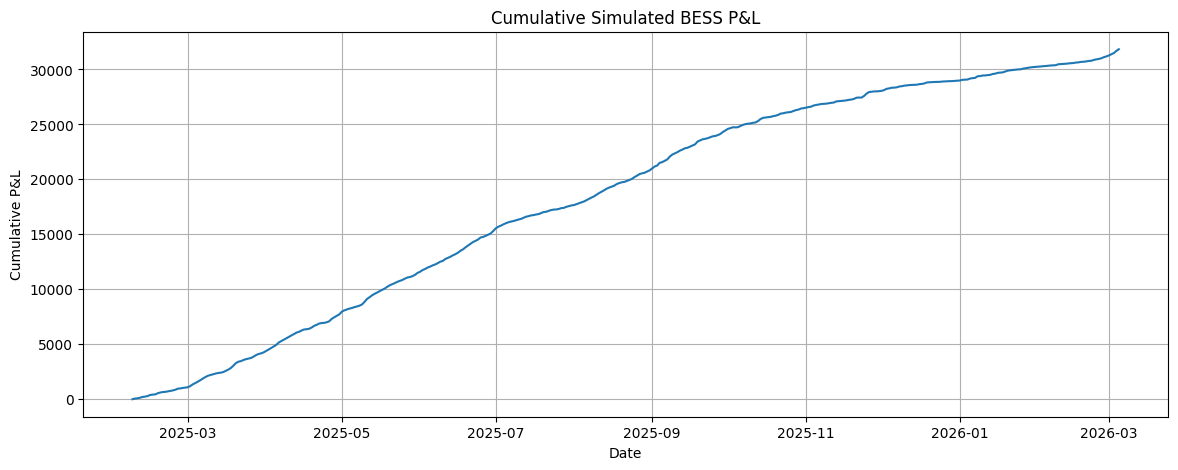

In [ ]:
# 17. CUMULATIVE P&L
# ============================================================

backtest_results["cumulative_pnl"] = backtest_results["daily_pnl"].cumsum()

plt.figure(figsize=(14, 5))
plt.plot(backtest_results["date"], backtest_results["cumulative_pnl"])
plt.title("Cumulative Simulated BESS P&L")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L")
plt.grid(True)
plt.show()

## 17. Cumulative P&L

This chart shows whether the simulated strategy is steadily profitable or unstable over time.

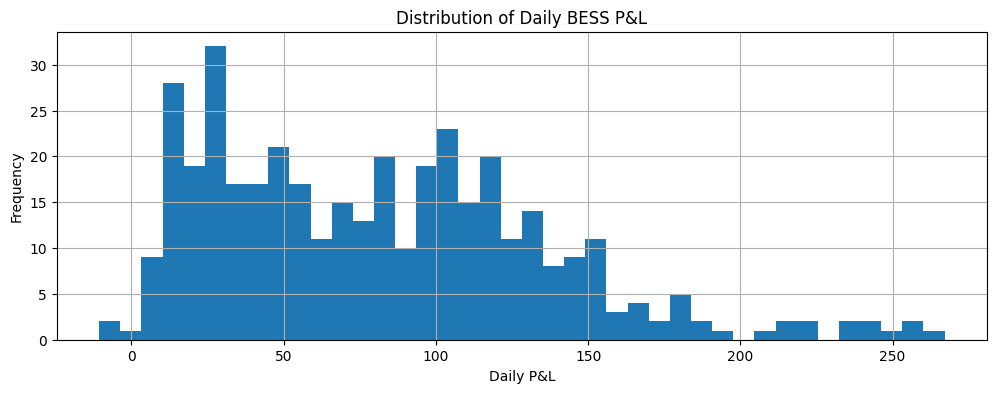

In [ ]:
# 18. DAILY P&L DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 4))
plt.hist(backtest_results["daily_pnl"], bins=40)
plt.title("Distribution of Daily BESS P&L")
plt.xlabel("Daily P&L")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## 18. Daily P&L distribution

This helps assess:
- how often the strategy wins or loses
- how variable daily performance is
- whether a few large days drive most profits

In [ ]:
# 19. ANNUALIZED REVENUE ESTIMATE
# ============================================================

days_simulated = len(backtest_results)

if days_simulated > 0:
    annualized_revenue = backtest_results["daily_pnl"].mean() * 365
else:
    annualized_revenue = np.nan

annualized_df = pd.DataFrame({
    "metric": ["Annualized revenue estimate"],
    "value": [annualized_revenue]
})

display(annualized_df)

,metric,value
0,Annualized revenue estimate,29644.5927


This annualizes the average daily simulated P&L.

Important:
This is only a first estimate.
A real business case would need:
- a fuller dispatch optimizer
- intraday constraints
- SOC tracking
- cycle limits
- ancillary market considerations

In [ ]:
#SIMPLE SENSITIVITY ANALYSIS
# ============================================================

sensitivity_rows = []

for eff in [0.85, 0.88, 0.90]:
    for deg_cost in [3.0, 5.0, 7.0]:
        res = simulate_daily_bess_arbitrage(
            sim_df,
            charge_hours_per_day=2,
            discharge_hours_per_day=2,
            battery_mwh=1.0,
            max_power_mw=1.0,
            round_trip_efficiency=eff,
            degradation_cost_per_mwh=deg_cost,
            grid_fee_per_mwh=2.0
        )
        sensitivity_rows.append({
            "round_trip_efficiency": eff,
            "degradation_cost_per_mwh": deg_cost,
            "total_pnl": res["daily_pnl"].sum(),
            "avg_daily_pnl": res["daily_pnl"].mean()
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.sort_values("total_pnl", ascending=False))

,round_trip_efficiency,degradation_cost_per_mwh,total_pnl,avg_daily_pnl
6,0.90,3.0,33874.119854,86.413571
3,0.88,3.0,33304.642428,84.960823
0,0.85,3.0,32438.151153,82.750386
7,0.90,5.0,32390.379175,82.628518
4,0.88,5.0,31837.480379,81.218062
1,0.85,5.0,30996.214400,79.071976
8,0.90,7.0,30906.638497,78.843466
5,0.88,7.0,30370.318329,77.475302
2,0.85,7.0,29554.277647,75.393565


This checks how the business case changes under different assumptions for:
- round-trip efficiency
- degradation cost

That is useful because economics can change a lot even when forecasting quality stays the same.

In [ ]:
# 21. FINAL SUMMARY TABLE
# ============================================================

best_forecasting_result = test_results.iloc[0].copy()

milestone_summary = pd.DataFrame({
    "item": [
        "Best forecasting model on test",
        "Best forecasting MAE",
        "Best forecasting RMSE",
        "Backtest total PnL",
        "Average daily PnL",
        "Annualized revenue estimate"
    ],
    "value": [
        best_forecasting_result["model"],
        best_forecasting_result["MAE"],
        best_forecasting_result["RMSE"],
        total_pnl,
        avg_daily_pnl,
        annualized_revenue
    ]
})

display(milestone_summary)

,item,value
0,Best forecasting model on test,XGBoost_Test
1,Best forecasting MAE,7.234872
2,Best forecasting RMSE,13.173378
3,Backtest total PnL,31837.480379
4,Average daily PnL,81.218062
5,Annualized revenue estimate,29644.5927


At this point we have delivered:

- optimized forecasting models
- feature ranking and optional SHAP interpretation
- model comparison table
- BESS arbitrage simulator
- backtest results
- first revenue estimate


## Forecasting conclusion
The best model should be selected based on validation first, then confirmed on test.

## Business conclusion
The forecasting model is only valuable if it produces useful trading decisions in the battery simulation.

## Key Week 3 output
The key bridge from data science to business value is:
predicted prices -> charge/discharge schedule -> simulated P&L
